In [1]:
import os
import sys
import shutil
import glob

# --- COLAB SETUP ---
try:
    from google.colab import drive
    IN_COLAB = True
    print("Running in Google Colab")

    drive.mount('/content/drive')

    REPO_URL = "https://github.com/zeynepoztunc/aml-procedural-mistake-detection.git"
    BRANCH = "main"

    if not os.path.exists('/content/code'):
        !git clone --recursive {REPO_URL} /content/code
        os.chdir('/content/code')
        !git fetch origin {BRANCH}
        !git checkout {BRANCH}
    else:
        os.chdir('/content/code')
        !git fetch origin {BRANCH}
        !git checkout {BRANCH}
        !git pull origin {BRANCH}

    if '/content/code' not in sys.path:
        sys.path.append('/content/code')

    # Install PyTorch Geometric
    !pip install -q torch-geometric

    # --- DATA SETUP ---
    DRIVE_BASE = "/content/drive/MyDrive/AML_Project"

    # Extract annotations from 1s.zip if needed
    data_zip = f"{DRIVE_BASE}/1s.zip"
    if not os.path.exists("annotations/annotation_json/step_annotations.json"):
        if os.path.exists(data_zip):
            print("Extracting annotations from 1s.zip...")
            !mkdir -p data
            !unzip -q -n "{data_zip}" -d data
            if os.path.exists("data/1s/annotations"):
                !cp -r data/1s/annotations .
            if os.path.exists("data/1s"):
                !rm -rf data/1s
            print("Annotations extracted.")

    # Copy step3 output from Drive if exists
    os.makedirs("extension_data", exist_ok=True)
    DRIVE_STEP3_OUTPUT = f"{DRIVE_BASE}/extension_data/realized_task_graphs.pkl"
    LOCAL_STEP3_OUTPUT = "extension_data/realized_task_graphs.pkl"

    if os.path.exists(DRIVE_STEP3_OUTPUT) and not os.path.exists(LOCAL_STEP3_OUTPUT):
        print("Copying step3 output from Drive...")
        !cp "{DRIVE_STEP3_OUTPUT}" "{LOCAL_STEP3_OUTPUT}"
        print("Done!")
    elif os.path.exists(LOCAL_STEP3_OUTPUT):
        print("Step3 output already exists locally.")
    else:
        print("WARNING: Step3 output not found. Run extension_step3 first!")

except ImportError:
    IN_COLAB = False
    print("Not running in Colab")

Running in Google Colab
Mounted at /content/drive
Cloning into '/content/code'...
remote: Enumerating objects: 992, done.
remote: Counting objects: 100% (206/206), done.
remote: Compressing objects: 100% (103/103), done.
remote: Total 992 (delta 133), reused 139 (delta 103), pack-reused 786 (from 2)
Receiving objects: 100% (992/992), 98.99 MiB | 19.61 MiB/s, done.
Resolving deltas: 100% (523/523), done.
Submodule 'annotations' (https://github.com/CaptainCook4D/annotations) registered for path 'annotations'
Cloning into '/content/code/annotations'...
remote: Enumerating objects: 152, done.        
remote: Counting objects: 100% (152/152), done.        
remote: Compressing objects: 100% (98/98), done.        
remote: Total 152 (delta 75), reused 108 (delta 46), pack-reused 0 (from 0)        
Receiving objects: 100% (152/152), 793.14 KiB | 18.03 MiB/s, done.
Resolving deltas: 100% (75/75), done.
Submodule path 'annotations': checked out '0e9a108be2cbcbcbd592e7418c0ab9c16232d27a'
From http

In [2]:
import pickle
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, balanced_accuracy_score)
from collections import defaultdict
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [3]:
# Import PyTorch Geometric
try:
    from torch_geometric.data import Data, Batch
    from torch_geometric.nn import SAGEConv, global_mean_pool, global_max_pool
    from torch_geometric.loader import DataLoader as PyGDataLoader
    from torch_geometric.utils import softmax as pyg_softmax   # DAGNN attention
    PYG_AVAILABLE = True
    print("PyTorch Geometric loaded successfully")
except ImportError:
    PYG_AVAILABLE = False
    print("PyTorch Geometric not available. Using simple baseline only.")

PyTorch Geometric loaded successfully


## 1. Load Realized Task Graphs

In [4]:
# Load the realized task graphs produced by Substep 3.
#
# Substep 3 writes one file per boundary source, and both are loaded here so that every
# model can be scored on both in a single pass:
#
# 'gt'           - annotated step boundaries. An oracle: the annotation lists only the
#                  steps that were performed.
# 'actionformer' - boundaries from an ActionFormer checkpoint trained on our EgoVLP 1s
#                  features. The step count now comes from a detector rather than from the
#                  annotation, so a missed detection and a skipped step look identical.


_GRAPH_FILES = {'gt': 'realized_task_graphs.pkl',
                'actionformer': 'realized_task_graphs_actionformer.pkl'}


def _resolve(filename):
    """Prefer the Drive copy in Colab, fall back to the local extension_data folder."""
    if IN_COLAB:
        drive = "/content/drive/MyDrive/AML_Project/extension_data/" + filename
        if os.path.exists(drive):
            return drive
    local = os.path.join("extension_data", filename)
    return local if os.path.exists(local) else None


GRAPHS_BY_SOURCE, SPLITS_BY_SOURCE = {}, {}
config = None
for _source, _filename in _GRAPH_FILES.items():
    _path = _resolve(_filename)
    if _path is None:
        print(f"  {_source:<14} not found ({_filename}) - skipped")
        continue
    with open(_path, 'rb') as f:
        _loaded = pickle.load(f)
    GRAPHS_BY_SOURCE[_source] = _loaded['realized_graphs']
    SPLITS_BY_SOURCE[_source] = _loaded['splits']
    config = _loaded['config']
    print(f"  {_source:<14} {len(_loaded['realized_graphs']):>3} graphs   "
          f"structure: {config.get('task_graph_source', 'unknown')}   {_path}")

assert GRAPHS_BY_SOURCE, ("No realized task graphs found. "
                          "Run extension_step3_task_graph_matching.ipynb first.")

SOURCES = list(GRAPHS_BY_SOURCE)
PRIMARY_SOURCE = 'gt' if 'gt' in GRAPHS_BY_SOURCE else SOURCES[0]
realized_graphs = GRAPHS_BY_SOURCE[PRIMARY_SOURCE]
splits = SPLITS_BY_SOURCE[PRIMARY_SOURCE]
print(f"\nSources: {SOURCES}   primary: {PRIMARY_SOURCE}")
print(f"Feature dimension: {config['feature_dim']}")


  gt             384 graphs   structure: captaincook4d_dag   /content/drive/MyDrive/AML_Project/extension_data/realized_task_graphs.pkl
  actionformer   384 graphs   structure: captaincook4d_dag   /content/drive/MyDrive/AML_Project/extension_data/realized_task_graphs_actionformer.pkl

Sources: ['gt', 'actionformer']   primary: gt
Feature dimension: 256


In [5]:
FEATURE_DIM = config['feature_dim']

# Substep 3 stores the text and visual node features separately so the projection can
# be learned here, and it stores where each matched step fell in the observed sequence
# so that order errors survive the matching. Fail loudly rather than silently falling
# back to an older format that has neither.
_sample = next(iter(realized_graphs.values()))
_required = ['node_text_features', 'node_visual_features', 'node_features', 'node_matched',
             'execution_rank', 'node_order_violations', 'num_order_violations',
             'num_comparable_edges']
_missing = [k for k in _required if k not in _sample]
assert not _missing, (
    f"realized_task_graphs.pkl is missing {_missing}. It was produced by an older "
    f"Substep 3. Re-run extension_step3_task_graph_matching.ipynb to regenerate it."
)
assert config.get('stores_execution_order'), (
    "This realized-graph file predates execution-order storage. Matching alone writes "
    "visual features onto canonical nodes and leaves the canonical edges unchanged, so "
    "'A then B' and 'B then A' realize identically - and Order Error is the largest error "
    "category in CaptainCook4D. Re-run Substep 3."
)

# Node input to the model is [visual | text | matched_flag | execution_rank | violations].
# The combiner inside each model fuses the first three blocks back down to FEATURE_DIM
# and passes the order block through untouched, so the GNN sees FEATURE_DIM + 2.
#
# The two order channels, per node:
#   execution_rank  position in the observed sequence, scaled to [0, 1]; -1 if the node
#                   was never matched, so "happened first" and "never happened" differ.
#   violations      canonical edges at this node whose direction the observed order
#                   contradicts, divided by the node's degree - bounded, and zero for a
#                   node whose prerequisites were all respected.
ORDER_FEATURE_DIM = 2
NODE_INPUT_DIM = 2 * FEATURE_DIM + 1 + ORDER_FEATURE_DIM
print(f"Feature dim: {FEATURE_DIM}, raw node input dim: {NODE_INPUT_DIM} "
      f"(+{ORDER_FEATURE_DIM} order channels)")

# Group by recipe type, per source
GROUPS_BY_SOURCE = {}
print(f"{'source':<14}{'recipes':>9}{'graphs':>8}{'nodes/graph':>13}"
      f"{'edges/graph':>13}{'incorrect':>11}")
print("-" * 68)
for source, graphs in GRAPHS_BY_SOURCE.items():
    groups = defaultdict(list)
    for recording_id, graph in graphs.items():
        groups[graph['recipe_id']].append(recording_id)
    GROUPS_BY_SOURCE[source] = groups

    n_nodes = [g['num_nodes'] for g in graphs.values()]
    n_edges = [g['edge_index'].shape[1] for g in graphs.values()]
    lab = [g['recipe_label'] for g in graphs.values()]
    print(f"{source:<14}{len(groups):>9}{len(graphs):>8}{np.mean(n_nodes):>13.1f}"
          f"{np.mean(n_edges):>13.1f}{np.mean(lab):>10.1%}")

recipe_groups = GROUPS_BY_SOURCE[PRIMARY_SOURCE]

Feature dim: 256, raw node input dim: 515 (+2 order channels)
source          recipes  graphs  nodes/graph  edges/graph  incorrect
--------------------------------------------------------------------
gt                   24     384         14.8         15.4     57.3%
actionformer         24     384         14.8         15.4     57.3%


## 2. Create PyG Data Objects

In [6]:
def create_pyg_data(realized_graph, recording_id, undirected=True):
    """
    Convert a realized graph to a PyTorch Geometric Data object.

    Node features are stacked as [visual | text | matched_flag | order] rather than
    pre-combined. The order block is what makes an order error visible at all: without
    it, a recording that performs B before A realizes to exactly the same graph as one
    that performs A before B, because matching writes visual features onto canonical
    nodes and the canonical edges never change.
    `undirected=True` (the default, chosen on the evidence in 8c) adds the reverse of
    every edge; `undirected=False` keeps the task graph's own direction.
    The combiner module inside each model turns that into the node representation, which
    is what lets the projection be *learned* from the classification loss instead
    of being a fixed average fixed at graph-construction time.
    """
    visual = np.asarray(realized_graph['node_visual_features'], dtype=np.float32)
    text = np.asarray(realized_graph['node_text_features'], dtype=np.float32)
    matched = np.asarray(realized_graph['node_matched'], dtype=np.float32).reshape(-1, 1)

    blocks = [visual, text, matched]
    if ORDER_FEATURE_DIM:
        rank = np.asarray(realized_graph['execution_rank'],
                          dtype=np.float32).reshape(-1, 1)

        # Violations are normalised by the node's degree in the CANONICAL graph, taken
        # before the symmetrisation below: a node with four prerequisites and one
        # violated edge should not outrank a node with one prerequisite that was
        # violated. Isolated nodes have degree 0 and cannot violate anything, so the
        # clamp only ever divides a zero.
        canonical = realized_graph['edge_index']
        degree = np.zeros(len(text), dtype=np.float32)
        if canonical.shape[1] > 0:
            np.add.at(degree, canonical[0], 1.0)
            np.add.at(degree, canonical[1], 1.0)
        violations = (np.asarray(realized_graph['node_order_violations'], dtype=np.float32)
                      / np.maximum(degree, 1.0)).reshape(-1, 1)
        blocks += [rank, violations]

    x = torch.FloatTensor(np.concatenate(blocks, axis=1))

    # CaptainCook4D task graphs are DAGs and the direction encodes procedural order, so
    # keeping it looks like the principled choice. We symmetrise instead, for a reason that
    # is specific to what each model needs:
    #
    #   Conventional message passing (GraphSAGE here) treats edges as an adjacency. Under
    #   directed edges a node only receives from its prerequisites, so every root node
    #   receives nothing. Symmetrising removes that asymmetry without inventing any
    #   relation that was not already in the graph. Section 8c confirms the choice does not
    #   move GraphSAGE either way, so it is not quietly driving the results.
    #
    #   DAGNN is the exception and takes `undirected=False`. It consumes the ordering
    #   rather than the adjacency: symmetrising would create cycles and leave topological
    #   depth undefined.
    #
    # So "does procedural direction carry information?" is answered by DAGNN's row in the
    # main table, not by this flag.
    edge_index = realized_graph['edge_index']
    if undirected and edge_index.shape[1] > 0:
        edge_index = np.concatenate(
            [edge_index, np.array([edge_index[1], edge_index[0]])], axis=1)
    edge_index = torch.LongTensor(edge_index)

    y = torch.FloatTensor([realized_graph['recipe_label']])

    node_matched = torch.FloatTensor(realized_graph['node_matched'].astype(float))
    match_sims = torch.FloatTensor(realized_graph['match_similarities'])

    data = Data(
        x=x,
        edge_index=edge_index,
        y=y,
        node_matched=node_matched,
        match_sims=match_sims,
        # Graph-level order summary. Carried for analysis, not read by any model - the
        # per-node channels above are the model's input.
        num_order_violations=torch.tensor([float(realized_graph['num_order_violations'])]),
        num_comparable_edges=torch.tensor([float(realized_graph['num_comparable_edges'])]),
        recording_id=recording_id,
        recipe_id=realized_graph['recipe_id']
    )

    return data

if PYG_AVAILABLE:
    PYG_BY_SOURCE = {
        source: {rid: create_pyg_data(g, rid) for rid, g in graphs.items()}
        for source, graphs in GRAPHS_BY_SOURCE.items()
    }
    pyg_data = PYG_BY_SOURCE[PRIMARY_SOURCE]

    for source, data in PYG_BY_SOURCE.items():
        print(f"  {source:<14} {len(data):>3} PyG Data objects")

    sample = list(pyg_data.values())[0]
    print(f"\nSample graph:")
    print(f"  Nodes: {sample.x.shape}  (expected [n, {NODE_INPUT_DIM}])")
    print(f"  Edges: {sample.edge_index.shape}")
    print(f"  Label: {sample.y.item()}")
    assert sample.x.shape[1] == NODE_INPUT_DIM

    # The order channels are only worth carrying if they vary. If no recording in the
    # set violates a single canonical edge, either the executions really are all in
    # order or Substep 3 failed to recover the ranks - and the models below would train
    # on a constant column either way.
    _viol = np.array([float(d.num_order_violations.item()) for d in pyg_data.values()])
    _comp = np.array([float(d.num_comparable_edges.item()) for d in pyg_data.values()])
    print(f"  Order    : {(_viol > 0).mean():.1%} of recordings violate at least one "
          f"canonical edge; {_viol.sum() / max(_comp.sum(), 1):.1%} of comparable edges")
    assert _viol.sum() > 0, (
        "No canonical edge is violated in any recording. Check that Substep 3 stored "
        "execution_rank from segment times rather than falling back to row order.")

  gt             384 PyG Data objects
  actionformer   384 PyG Data objects

Sample graph:
  Nodes: torch.Size([12, 515])  (expected [n, 515])
  Edges: torch.Size([2, 22])
  Label: 0.0
  Order    : 98.4% of recordings violate at least one canonical edge; 39.4% of comparable edges


## 3. Define GNN Models

In [7]:
# ==============================================================================
# Node feature combiners
# ==============================================================================
# The learnable projection of node text features and matched visual features lives
# here, not in Substep 3, because it can only be *learned* where
# there is a loss to train it. Substep 3 has no objective, so a projector instantiated
# there would apply a fixed random transform. Here it is the first module of the GNN and
# is trained end-to-end by the graph classification loss.
#
# Both combiners take the same raw node input [visual | text | matched_flag | order] so
# the two can be compared as a clean ablation on identical data and folds. Neither one
# touches the order block: fusing a scalar position into a 256-d embedding would bury it,
# and it is not a modality to be projected - it is a structural fact about the execution.
# Both therefore pass it through unchanged and report the widened `out_dim`, which is what
# every model uses to size its first layer.

class LearnableProjection(nn.Module):
    """The learnable projection, applied to the MATCHED nodes only.

    Only matched nodes are updated. An unmatched node has no
    visual evidence - its visual block is all zeros - so there is nothing to fuse, and
    it should keep the task graph's own text representation.

    An earlier version ran the projection over every node, including unmatched ones.
    That transformed nodes which should have been left alone, and it also made this module
    differ from FixedAverage in two ways at once (the fusion rule *and* whether
    unmatched nodes are touched), which muddied the ablation between them. Both now
    share the same gate, so the comparison isolates the fusion rule alone.
    """

    def __init__(self, feature_dim, hidden_dim=256, extra_dim=0):
        super().__init__()
        self.feature_dim = feature_dim
        self.extra_dim = extra_dim
        self.out_dim = feature_dim + extra_dim
        self.proj = nn.Sequential(
            nn.Linear(feature_dim * 2, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, feature_dim),
            nn.LayerNorm(feature_dim)
        )

    def forward(self, x):
        d = self.feature_dim
        visual, text, matched = x[:, :d], x[:, d:2 * d], x[:, 2 * d:2 * d + 1]
        fused = self.proj(torch.cat([text, visual], dim=-1))
        out = matched * fused + (1.0 - matched) * text
        if self.extra_dim:
            out = torch.cat([out, x[:, 2 * d + 1:2 * d + 1 + self.extra_dim]], dim=-1)
        return out


class FixedAverage(nn.Module):
    """No-projection baseline, reproducing Substep 3's `node_features` exactly.

    Matched nodes get 0.5*visual + 0.5*text; unmatched nodes keep their text embedding
    (their visual slot is all zeros, so the matched flag is what selects between them).
    Has no parameters, so any gap against LearnableProjection is attributable to the
    projection itself rather than to extra capacity elsewhere.
    """

    def __init__(self, feature_dim, extra_dim=0):
        super().__init__()
        self.feature_dim = feature_dim
        self.extra_dim = extra_dim
        self.out_dim = feature_dim + extra_dim

    def forward(self, x):
        d = self.feature_dim
        visual, text, matched = x[:, :d], x[:, d:2 * d], x[:, 2 * d:2 * d + 1]
        out = matched * (0.5 * visual + 0.5 * text) + (1.0 - matched) * text
        if self.extra_dim:
            out = torch.cat([out, x[:, 2 * d + 1:2 * d + 1 + self.extra_dim]], dim=-1)
        return out


def make_combiner(kind, feature_dim, hidden_dim=256, extra_dim=None):
    """Build a combiner. `extra_dim` defaults to however many order channels the graphs
    carry, so the models below need no argument threaded through the LORO harness."""
    if extra_dim is None:
        extra_dim = globals().get('ORDER_FEATURE_DIM', 0)
    if kind == 'projection':
        return LearnableProjection(feature_dim, hidden_dim, extra_dim=extra_dim)
    if kind == 'average':
        return FixedAverage(feature_dim, extra_dim=extra_dim)
    raise ValueError(f"unknown combiner: {kind!r} (expected 'projection' or 'average')")


if PYG_AVAILABLE:

    class GraphSAGEClassifier(nn.Module):
        """GraphSAGE for graph classification."""

        def __init__(self, input_dim, hidden_dim=128, num_layers=3, dropout=0.3,
                     combine='projection'):
            super().__init__()
            self.combiner = make_combiner(combine, input_dim, hidden_dim=256)

            self.convs = nn.ModuleList()
            self.bns = nn.ModuleList()

            self.convs.append(SAGEConv(self.combiner.out_dim, hidden_dim))
            self.bns.append(nn.BatchNorm1d(hidden_dim))

            for _ in range(num_layers - 1):
                self.convs.append(SAGEConv(hidden_dim, hidden_dim))
                self.bns.append(nn.BatchNorm1d(hidden_dim))

            self.dropout = nn.Dropout(dropout)

            self.classifier = nn.Sequential(
                nn.Linear(hidden_dim * 2, hidden_dim),
                nn.ReLU(),
                nn.Dropout(dropout),
                nn.Linear(hidden_dim, 1)
            )

        def forward(self, x, edge_index, batch):
            x = self.combiner(x)

            for conv, bn in zip(self.convs, self.bns):
                x = conv(x, edge_index)
                x = bn(x)
                x = F.relu(x)
                x = self.dropout(x)

            x_mean = global_mean_pool(x, batch)
            x_max = global_max_pool(x, batch)
            x = torch.cat([x_mean, x_max], dim=-1)

            return self.classifier(x)



    class DAGNNClassifier(nn.Module):
        """DAGNN (Thost and Chen, ICLR 2021), the layer designed for DAGs.

        GCN, GAT and GraphSAGE update every node at once from its immediate neighbours,
        so k layers reach k hops and the direction of an edge only decides who is in the
        neighbourhood. DAGNN instead processes nodes in topological order: a node is
        updated only after all of its predecessors have been updated *within the same
        layer*, using an attention-weighted aggregate of their current states and a GRU
        update. One layer therefore propagates information along an entire path, and the
        DAG's direction is what defines the computation rather than merely restricting it.

        This is the direct test of the edge-direction ablation further down. Symmetrising
        the graph beats keeping its direction for every conventional layer, which admits
        two readings: either procedural order carries no usable signal, or those layers
        cannot exploit it. DAGNN is built for precisely this structure, so it separates
        the two. It is the only model here that requires directed edges - run it on
        `create_pyg_data(..., undirected=False)`.

        Two deliberate deviations from the paper, both so that the comparison isolates
        the layer rather than the surrounding architecture:
          - readout is mean+max pooling over all nodes, not the sink-node representation,
            matching every other model in this notebook;
          - a single direction (predecessors -> successors), not the bidirectional variant.

        Cost: the level sweep is sequential by construction, and these graphs run to a
        topological depth of 19, so a forward pass performs depth x num_layers = up to 57
        small sequential steps where a GCN performs 3 dense ones. Measured at roughly 8x
        GCN's wall-clock here. That is the price of the ordering, not an inefficiency to
        optimise away.
        """

        def __init__(self, input_dim, hidden_dim=128, num_layers=3, dropout=0.3,
                     combine='projection'):
            super().__init__()
            self.combiner = make_combiner(combine, input_dim, hidden_dim=256)
            self.num_layers = num_layers
            self.hidden_dim = hidden_dim

            self.input_proj = nn.Linear(self.combiner.out_dim, hidden_dim)

            # Per-layer attention over a node's predecessors, and the GRU that folds the
            # aggregated message into the node's previous-layer state.
            self.att_query = nn.ModuleList()
            self.att_key = nn.ModuleList()
            self.att_score = nn.ModuleList()
            self.grus = nn.ModuleList()
            self.bns = nn.ModuleList()
            for _ in range(num_layers):
                self.att_query.append(nn.Linear(hidden_dim, hidden_dim))
                self.att_key.append(nn.Linear(hidden_dim, hidden_dim))
                self.att_score.append(nn.Linear(hidden_dim, 1))
                self.grus.append(nn.GRUCell(hidden_dim, hidden_dim))
                self.bns.append(nn.BatchNorm1d(hidden_dim))

            self.dropout = nn.Dropout(dropout)
            self.classifier = nn.Sequential(
                nn.Linear(hidden_dim * 2, hidden_dim),
                nn.ReLU(),
                nn.Dropout(dropout),
                nn.Linear(hidden_dim, 1)
            )

        @staticmethod
        def _topological_depth(edge_index, num_nodes, device):
            """Longest-path depth of every node; sources are 0.

            Computed on the batched graph, which is safe: PyG batches disjoint graphs
            into one disconnected graph, so no path crosses a recording boundary. The
            relaxation converges in at most (longest path) rounds and is bounded by
            num_nodes so a cyclic input cannot hang.
            """
            depth = torch.zeros(num_nodes, dtype=torch.long, device=device)
            if edge_index.numel() == 0:
                return depth
            src, dst = edge_index[0], edge_index[1]
            for _ in range(num_nodes):
                proposed = depth.clone()
                proposed.scatter_reduce_(0, dst, depth[src] + 1,
                                         reduce='amax', include_self=True)
                if torch.equal(proposed, depth):
                    break
                depth = proposed
            return depth

        def forward(self, x, edge_index, batch):
            h = self.input_proj(self.combiner(x))
            num_nodes = h.size(0)

            depth = self._topological_depth(edge_index, num_nodes, h.device)
            max_depth = int(depth.max().item()) if num_nodes > 0 else 0
            has_edges = edge_index.numel() > 0
            if has_edges:
                src, dst = edge_index[0], edge_index[1]
                dst_depth = depth[dst]

            for layer in range(self.num_layers):
                h_prev = h
                h_cur = h_prev
                # Sweep the topological levels in order. Nodes at depth 0 have no
                # predecessors and keep their previous-layer state, which is what the
                # paper does for source nodes.
                for d in range(1, max_depth + 1):
                    if not has_edges:
                        break
                    sel = dst_depth == d
                    if not bool(sel.any()):
                        continue
                    e_src, e_dst = src[sel], dst[sel]

                    # Work only on the nodes at this level. Doing the GRU update over all
                    # N nodes and masking afterwards is far simpler to write, but this
                    # inner loop runs (max depth x num_layers) times per forward pass -
                    # about 45 times on these graphs - so the wasted work dominates.
                    targets, local = torch.unique(e_dst, return_inverse=True)

                    # Attention: the query is the target's previous-layer state, the key
                    # is the predecessor's state as already updated in this layer.
                    q = self.att_query[layer](h_prev[e_dst])
                    k = self.att_key[layer](h_cur[e_src])
                    score = self.att_score[layer](torch.tanh(q + k)).squeeze(-1)
                    alpha = pyg_softmax(score, local, num_nodes=targets.size(0))

                    message = torch.zeros(targets.size(0), self.hidden_dim,
                                          device=h.device, dtype=h_cur.dtype)
                    message = message.index_add(0, local,
                                                alpha.unsqueeze(-1) * h_cur[e_src])

                    updated = self.grus[layer](message, h_prev[targets])
                    h_cur = h_cur.index_copy(0, targets, updated)

                h = self.dropout(F.relu(self.bns[layer](h_cur)))

            x_mean = global_mean_pool(h, batch)
            x_max = global_max_pool(h, batch)
            return self.classifier(torch.cat([x_mean, x_max], dim=-1))


    print("GNN models defined: GraphSAGE, DAGNN"
          " (combiner: 'projection' | 'average')")


GNN models defined: GraphSAGE, DAGNN (combiner: 'projection' | 'average')


In [8]:
# Simple baseline without GNN (for comparison)
class SimplePoolingClassifier(nn.Module):
    """Ignores the graph structure: combine node features, pool, classify.

    This is the control for "does the task graph topology matter at all?" - it sees
    exactly the same node features as the GNNs but never propagates along an edge.
    """

    def __init__(self, input_dim, hidden_dim=128, dropout=0.3, combine='projection'):
        super().__init__()
        self.combiner = make_combiner(combine, input_dim, hidden_dim=256)

        self.fc = nn.Sequential(
            nn.Linear(self.combiner.out_dim * 2, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, 1)
        )

    def forward(self, x, edge_index, batch):
        x = self.combiner(x)

        if PYG_AVAILABLE:
            x_mean = global_mean_pool(x, batch)
            x_max = global_max_pool(x, batch)
        else:
            x_mean = x.mean(dim=0, keepdim=True)
            x_max = x.max(dim=0, keepdim=True)[0]

        x = torch.cat([x_mean, x_max], dim=-1)
        return self.fc(x)

print("Simple baseline defined")

Simple baseline defined


## 4. Training Functions

In [9]:
def train_epoch_gnn(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    all_preds = []
    all_labels = []

    for batch in loader:
        batch = batch.to(device)

        optimizer.zero_grad()
        out = model(batch.x, batch.edge_index, batch.batch)
        loss = criterion(out, batch.y.view(-1, 1))
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item() * batch.num_graphs

        preds = torch.sigmoid(out).detach().cpu().numpy()
        all_preds.extend(preds.flatten())
        all_labels.extend(batch.y.cpu().numpy().flatten())

    return total_loss / len(loader.dataset), np.array(all_preds), np.array(all_labels)


def evaluate_gnn(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            out = model(batch.x, batch.edge_index, batch.batch)
            loss = criterion(out, batch.y.view(-1, 1))

            total_loss += loss.item() * batch.num_graphs

            preds = torch.sigmoid(out).cpu().numpy()
            all_preds.extend(preds.flatten())
            all_labels.extend(batch.y.cpu().numpy().flatten())

    return total_loss / len(loader.dataset), np.array(all_preds), np.array(all_labels)


def compute_metrics(preds, labels, threshold=0.5, majority_class=None):
    """Metrics for a binary task with a ~61/39 class split.

    `preds` are probabilities, so AUC is computed on them directly rather than on
    thresholded predictions (thresholding first destroys the ranking AUC measures and
    pins it near the accuracy).

    Balanced accuracy is reported alongside F1 because F1 on the positive (majority)
    class rewards a model that predicts "incorrect" for everything - that degenerate
    predictor scores ~76% F1 here while being useless.
    """
    binary_preds = (preds >= threshold).astype(int)

    metrics = {
        'accuracy': accuracy_score(labels, binary_preds),
        'precision': precision_score(labels, binary_preds, zero_division=0),
        'recall': recall_score(labels, binary_preds, zero_division=0),
        'f1': f1_score(labels, binary_preds, zero_division=0),
        'balanced_accuracy': balanced_accuracy_score(labels, binary_preds),
        'positive_rate': float(binary_preds.mean()),
    }

    try:
        metrics['auc'] = roc_auc_score(labels, preds)
    except ValueError:
        # Only one class present in this fold - AUC undefined.
        metrics['auc'] = float('nan')

    # Majority-class baseline. The class MUST come from the training labels; deriving it
    # from the test labels leaks the answer and flatters the baseline.
    if majority_class is not None:
        const = np.full_like(binary_preds, int(majority_class))
        metrics['majority_f1'] = f1_score(labels, const, zero_division=0)
        metrics['majority_accuracy'] = accuracy_score(labels, const)
        metrics['majority_balanced_accuracy'] = balanced_accuracy_score(labels, const)

    return metrics

## 5. Leave-One-Recipe-Out Evaluation

In [10]:
def leave_one_recipe_out_gnn(model_class, pyg_data, recipe_groups, input_dim,
                             num_epochs=50, lr=1e-3, batch_size=32,
                             pos_weight='auto', n_val_recipes=4, seed=0,
                             refit_on_full=False, verbose=True, **model_kwargs):
    """Nested leave-one-recipe-out cross-validation.

    Three properties make this protocol trustworthy:

    1. **A real validation split.** The recipes not under test are split into an inner
       training set and a held-out validation set of `n_val_recipes` recipes, and the
       epoch is chosen on validation loss. Selecting on training loss instead would
       always return the most overfit checkpoint, since it decreases monotonically.
       Splitting by recipe rather than by recording matters because recordings of the
       same recipe are near-duplicates of one another.

    2. **pos_weight derived from the data.** 57% of recordings are labelled incorrect,
       so a fixed pos_weight above 1.0 up-weights the majority class and pushes the
       model toward the degenerate all-positive predictor. 'auto' uses n_neg/n_pos
       computed on the training fold only.

    3. **Controlled randomness, not determinism.** Each fold seeds torch, which fixes
       weight initialisation and data order so two configurations are compared under the
       same draw. It does NOT make a run reproducible: PyG's scatter reductions and CUDA
       attention kernels are non-deterministic, and re-running this notebook unchanged
       moved pooled AUC by up to 2 points on an attention-based layer, while SimplePooling, which has no
       scatter over edges, moved by 0.1. Treat differences of a few AUC points between
       configurations as unresolved.

    `refit_on_full=True` switches to the textbook nested-CV variant: after the inner
    split has chosen an epoch, the model is retrained from scratch for that many epochs
    on all k-1 non-test recipes, so the validation recipes contribute to the final fit.
    Default is False, which reports the model actually selected on validation. Both are
    leak-free; the refit uses the limited data more efficiently, at the cost of a second
    training run per fold.

    Returns (per_fold_results, pooled_predictions) where pooled_predictions holds the
    concatenated test probabilities and labels across all folds.
    """
    recipe_ids = sorted(recipe_groups.keys())
    all_results = []
    pooled_probs, pooled_labels, pooled_majority = [], [], []

    if verbose:
        print(f"\nNested leave-one-recipe-out over {len(recipe_ids)} recipes "
              f"({n_val_recipes} held out for validation inside each fold)")

    for fold_idx, test_recipe in enumerate(tqdm(recipe_ids, desc="Folds")):
        test_ids = [r for r in recipe_groups[test_recipe] if r in pyg_data]

        other_recipes = [r for r in recipe_ids if r != test_recipe]
        rng = np.random.default_rng(seed + fold_idx)
        rng.shuffle(other_recipes)

        val_recipes = other_recipes[:n_val_recipes]
        train_recipes = other_recipes[n_val_recipes:]

        train_ids = [r for rec in train_recipes for r in recipe_groups[rec] if r in pyg_data]
        val_ids = [r for rec in val_recipes for r in recipe_groups[rec] if r in pyg_data]

        if len(test_ids) < 2 or len(train_ids) < 10 or len(val_ids) < 2:
            continue

        train_data = [pyg_data[r] for r in train_ids]
        val_data = [pyg_data[r] for r in val_ids]
        test_data = [pyg_data[r] for r in test_ids]

        train_loader = PyGDataLoader(train_data, batch_size=batch_size, shuffle=True)
        val_loader = PyGDataLoader(val_data, batch_size=batch_size, shuffle=False)
        test_loader = PyGDataLoader(test_data, batch_size=batch_size, shuffle=False)

        # --- training-fold statistics only -------------------------------------
        train_labels = np.array([float(pyg_data[r].y.item()) for r in train_ids])
        n_pos = float(train_labels.sum())
        n_neg = float(len(train_labels) - n_pos)
        majority_class = int(n_pos >= n_neg)

        if pos_weight == 'auto':
            fold_pos_weight = (n_neg / n_pos) if n_pos > 0 else 1.0
        else:
            fold_pos_weight = float(pos_weight)

        torch.manual_seed(seed + fold_idx)
        model = model_class(input_dim, **model_kwargs).to(device)

        criterion = nn.BCEWithLogitsLoss(
            pos_weight=torch.tensor([fold_pos_weight], device=device))
        optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)

        best_val_loss = float('inf')
        best_state = None
        best_epoch = -1

        for epoch in range(num_epochs):
            train_epoch_gnn(model, train_loader, optimizer, criterion, device)
            scheduler.step()

            val_loss, _, _ = evaluate_gnn(model, val_loader, criterion, device)
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}
                best_epoch = epoch

        if refit_on_full and best_epoch >= 0:
            # Standard nested-CV refit: the inner split existed only to choose the
            # epoch, so retrain from scratch for that many epochs on ALL k-1 non-test
            # recipes. Uses the fold's data more efficiently at the cost of a second
            # training run; pos_weight is recomputed on the enlarged training set and
            # the test recipe is still never touched.
            full_ids = train_ids + val_ids
            full_loader = PyGDataLoader([pyg_data[r] for r in full_ids],
                                        batch_size=batch_size, shuffle=True)
            full_labels = np.array([float(pyg_data[r].y.item()) for r in full_ids])
            f_pos = float(full_labels.sum())
            f_neg = float(len(full_labels) - f_pos)
            f_weight = (f_neg / f_pos) if (pos_weight == 'auto' and f_pos > 0) \
                else fold_pos_weight

            torch.manual_seed(seed + fold_idx)
            model = model_class(input_dim, **model_kwargs).to(device)
            criterion = nn.BCEWithLogitsLoss(
                pos_weight=torch.tensor([f_weight], device=device))
            optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
            scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
                optimizer, T_max=max(best_epoch + 1, 1))
            for _ in range(best_epoch + 1):
                train_epoch_gnn(model, full_loader, optimizer, criterion, device)
                scheduler.step()
        elif best_state is not None:
            model.load_state_dict(best_state)

        # --- test fold, untouched until here -----------------------------------
        _, test_probs, test_labels = evaluate_gnn(model, test_loader, criterion, device)
        metrics = compute_metrics(test_probs, test_labels, majority_class=majority_class)

        pooled_probs.append(test_probs)
        pooled_labels.append(test_labels)
        pooled_majority.append(np.full_like(test_labels, majority_class))

        all_results.append({
            'fold': fold_idx,
            'test_recipe': test_recipe,
            'train_size': len(train_ids),
            'val_size': len(val_ids),
            'test_size': len(test_ids),
            'pos_weight': fold_pos_weight,
            'selected_epoch': best_epoch,
            **metrics
        })

    pooled = {
        'probs': np.concatenate(pooled_probs) if pooled_probs else np.array([]),
        'labels': np.concatenate(pooled_labels) if pooled_labels else np.array([]),
        'majority': np.concatenate(pooled_majority) if pooled_majority else np.array([]),
    }

    return all_results, pooled


def summarize_results(results, pooled, model_name, num_epochs=None):
    """Report POOLED metrics as the headline.

    Folds hold 3-6 recordings, so a single fold's F1 can take only a handful of discrete
    values, and averaging across folds additionally weights every recipe equally
    regardless of size. Pooling the predictions across folds and scoring once avoids
    both effects; the per-fold spread is retained as a dispersion diagnostic.
    """
    metric_names = ['accuracy', 'precision', 'recall', 'f1', 'balanced_accuracy', 'auc']

    probs, labels, majority = pooled['probs'], pooled['labels'], pooled['majority']
    binary = (probs >= 0.5).astype(int)

    pooled_metrics = {
        'accuracy': accuracy_score(labels, binary),
        'precision': precision_score(labels, binary, zero_division=0),
        'recall': recall_score(labels, binary, zero_division=0),
        'f1': f1_score(labels, binary, zero_division=0),
        'balanced_accuracy': balanced_accuracy_score(labels, binary),
        'auc': roc_auc_score(labels, probs),
    }
    majority_metrics = {
        'accuracy': accuracy_score(labels, majority),
        'f1': f1_score(labels, majority, zero_division=0),
        'balanced_accuracy': balanced_accuracy_score(labels, majority),
        'auc': 0.5,
    }

    print(f"\n{'='*66}")
    print(f"{model_name}  -  pooled over {len(results)} folds, {len(labels)} recordings")
    print(f"{'='*66}")
    print(f"{'metric':<20}{'model':>12}{'majority':>12}")
    for m in metric_names:
        maj = majority_metrics.get(m)
        maj_str = f"{maj*100:>11.2f}%" if maj is not None else f"{'-':>12}"
        print(f"{m:<20}{pooled_metrics[m]*100:>11.2f}%{maj_str}")

    print(f"\nPer-fold spread (diagnostic, not the headline):")
    for m in metric_names:
        vals = [r[m] for r in results if not np.isnan(r[m])]
        print(f"  {m:<18}{np.mean(vals)*100:>7.2f}% +/- {np.std(vals)*100:.2f}%")

    sel = [r['selected_epoch'] for r in results]
    tail = f" of {num_epochs}" if num_epochs else ""
    print(f"\nSelected epoch: mean {np.mean(sel):.1f}{tail}, "
          f"median {np.median(sel):.0f}, max {np.max(sel)}")
    if num_epochs and np.mean(sel) < 0.1 * num_epochs:
        # Converging early is not the same as failing. Decide from the pooled AUC
        # whether the model learned something before it started overfitting.
        if pooled_metrics['auc'] > 0.60:
            verdict = ("it still beats the baseline comfortably, so this is fast "
                       "convergence followed by overfitting, not failure to learn")
        else:
            verdict = ("and it does not beat the baseline: the model is memorising "
                       "the training folds rather than learning from them")
        print(f"  -> validation loss bottoms out within the first few epochs; {verdict}.")
    print(f"Positive rate: {binary.mean():.2%} (true: {labels.mean():.2%})")
    print(f"{'='*66}")

    out = {m: {'pooled': pooled_metrics[m],
               'fold_mean': float(np.mean([r[m] for r in results if not np.isnan(r[m])])),
               'fold_std': float(np.std([r[m] for r in results if not np.isnan(r[m])]))}
           for m in metric_names}
    out['_majority'] = majority_metrics
    out['_selected_epoch_mean'] = float(np.mean(sel))
    return out

## 6. Train and Evaluate All Models

In [11]:
# ==============================================================================
# EXPERIMENT CONFIGURATION
# ==============================================================================

NUM_EPOCHS = 50
LEARNING_RATE = 1e-3
BATCH_SIZE = 32
POS_WEIGHT = 'auto'      # n_neg/n_pos on the training fold; was hardcoded 2.0
HIDDEN_DIM = 128
NUM_LAYERS = 3
N_VAL_RECIPES = 4        # inner validation split, by recipe
SEED = 0
COMBINE = 'projection'   # 'projection' or 'average' (no-projection baseline)

# Three models, each answering a question the other two cannot:
#
#   SimplePooling  no edges at all. The control. If message passing is worth anything,
#                  it has to show up as a gap over this.
#   GraphSAGE      conventional message passing on the symmetrised graph. Chosen over
#                  GCN and GAT because it was the strongest of the three on annotated
#                  boundaries and the most stable: it keeps a separate self-pathway, so
#                  it is the one layer whose score does not depend on whether the edges
#                  are symmetrised.
#   DAGNN          topological-order processing with a GRU update, the layer designed
#                  for directed acyclic graphs. The only model here
#                  that consumes the DAG's direction as direction rather than as an
#                  adjacency.
#
# GCN and GAT were measured and dropped. Two conventional convolutions told us nothing a
# third did not, and neither beat SimplePooling. Their numbers are kept in the write-up
# notes rather than re-derived on every run.
MODEL_ROSTER = ['SimplePooling', 'GraphSAGE', 'DAGNN']

# DAGNN needs the DAG's own direction: it walks the graph in topological order, so
# symmetrising the edges would create cycles and make node depth undefined. Everything
# else uses the symmetrised default.
NEEDS_DIRECTED = {'DAGNN'}

print("Configuration")
print(f"  epochs={NUM_EPOCHS}  lr={LEARNING_RATE}  batch={BATCH_SIZE}")
print(f"  hidden={HIDDEN_DIM}  layers={NUM_LAYERS}  combiner={COMBINE}")
print(f"  pos_weight={POS_WEIGHT}  val_recipes={N_VAL_RECIPES}  seed={SEED}")
print(f"  roster={MODEL_ROSTER}")
print(f"  directed-edge models={sorted(NEEDS_DIRECTED)}")

all_model_results = {}
all_fold_results = {}


Configuration
  epochs=50  lr=0.001  batch=32
  hidden=128  layers=3  combiner=projection
  pos_weight=auto  val_recipes=4  seed=0
  roster=['SimplePooling', 'GraphSAGE', 'DAGNN']
  directed-edge models=['DAGNN']


In [12]:
# ==============================================================================
# MAIN COMPARISON: every model in the roster, on every boundary source
# ==============================================================================
# One loop rather than one cell per model, so adding or removing a model is a change to
# MODEL_ROSTER above and nothing else.

if PYG_AVAILABLE:

    MODEL_CLASSES = {
        'SimplePooling': SimplePoolingClassifier,
        'GraphSAGE': GraphSAGEClassifier,
        'DAGNN': DAGNNClassifier,
    }

    # Directed copies of every graph, for the models that need the DAG's own direction.
    DIRECTED_BY_SOURCE = {
        source: {rid: create_pyg_data(g, rid, undirected=False)
                 for rid, g in graphs.items()}
        for source, graphs in GRAPHS_BY_SOURCE.items()
    }

    for model_name in MODEL_ROSTER:
        directed = model_name in NEEDS_DIRECTED

        for source in SOURCES:
            data = (DIRECTED_BY_SOURCE if directed else PYG_BY_SOURCE)[source]
            edge_kind = 'directed' if directed else 'undirected'

            print("\n" + "=" * 66)
            print(f"Training {model_name} - {source} boundaries ({edge_kind} edges)")
            print("=" * 66)

            kwargs = dict(
                input_dim=FEATURE_DIM,
                num_epochs=NUM_EPOCHS,
                lr=LEARNING_RATE,
                batch_size=BATCH_SIZE,
                pos_weight=POS_WEIGHT,
                n_val_recipes=N_VAL_RECIPES,
                seed=SEED,
                hidden_dim=HIDDEN_DIM,
                combine=COMBINE,
            )
            if model_name != 'SimplePooling':      # the pooling baseline has no layers
                kwargs['num_layers'] = NUM_LAYERS

            _folds, _pooled = leave_one_recipe_out_gnn(
                MODEL_CLASSES[model_name],
                data,
                GROUPS_BY_SOURCE[source],
                **kwargs
            )

            all_fold_results[(source, model_name)] = _folds
            all_model_results[(source, model_name)] = summarize_results(
                _folds, _pooled,
                f"{model_name} - {source} boundaries",
                num_epochs=NUM_EPOCHS)



Training SimplePooling - gt boundaries (undirected edges)

Nested leave-one-recipe-out over 24 recipes (4 held out for validation inside each fold)


Folds: 100%|██████████| 24/24 [01:37<00:00,  4.05s/it]



SimplePooling - gt boundaries  -  pooled over 24 folds, 384 recordings
metric                     model    majority
accuracy                  74.48%      57.29%
precision                 89.10%           -
recall                    63.18%           -
f1                        73.94%      72.85%
balanced_accuracy         76.41%      50.00%
auc                       80.60%      50.00%

Per-fold spread (diagnostic, not the headline):
  accuracy            74.33% +/- 11.22%
  precision           90.07% +/- 14.62%
  recall              62.67% +/- 19.10%
  f1                  71.76% +/- 14.12%
  balanced_accuracy   76.45% +/- 10.63%
  auc                 84.47% +/- 9.73%

Selected epoch: mean 4.1 of 50, median 4, max 7
  -> validation loss bottoms out within the first few epochs; it still beats the baseline comfortably, so this is fast convergence followed by overfitting, not failure to learn.
Positive rate: 40.62% (true: 57.29%)

Training SimplePooling - actionformer boundaries (undirected

Folds: 100%|██████████| 24/24 [01:36<00:00,  4.02s/it]



SimplePooling - actionformer boundaries  -  pooled over 24 folds, 384 recordings
metric                     model    majority
accuracy                  66.67%      57.29%
precision                 72.12%           -
recall                    68.18%           -
f1                        70.09%      72.85%
balanced_accuracy         66.41%      50.00%
auc                       72.15%      50.00%

Per-fold spread (diagnostic, not the headline):
  accuracy            66.68% +/- 10.72%
  precision           73.17% +/- 14.33%
  recall              67.27% +/- 20.80%
  f1                  67.74% +/- 14.13%
  balanced_accuracy   64.73% +/- 10.08%
  auc                 74.56% +/- 10.31%

Selected epoch: mean 4.4 of 50, median 4, max 9
  -> validation loss bottoms out within the first few epochs; it still beats the baseline comfortably, so this is fast convergence followed by overfitting, not failure to learn.
Positive rate: 54.17% (true: 57.29%)

Training GraphSAGE - gt boundaries (undirected ed

...


GraphSAGE - actionformer boundaries  -  pooled over 24 folds, 384 recordings
metric                     model    majority
accuracy                  61.46%      57.29%
precision                 72.78%           -
recall                    52.27%           -
f1                        60.85%      72.85%
balanced_accuracy         63.03%      50.00%
auc                       65.93%      50.00%

Per-fold spread (diagnostic, not the headline):
  accuracy            61.22% +/- 10.81%
  precision           80.88% +/- 18.17%
  recall              52.60% +/- 29.22%
  f1                  55.84% +/- 19.53%
  balanced_accuracy   62.02% +/- 7.69%
  auc                 73.36% +/- 11.33%

Selected epoch: mean 1.9 of 50, median 2, max 5
  -> validation loss bottoms out within the first few epochs; it still beats the baseline comfortably, so this is fast convergence followed by overfitting, not failure to learn.
Positive rate: 41.15% (true: 57.29%)

Training DAGNN - gt boundaries (directed edges)

Neste

Folds: 100%|██████████| 24/24 [31:10<00:00, 77.95s/it]



DAGNN - gt boundaries  -  pooled over 24 folds, 384 recordings
metric                     model    majority
accuracy                  75.00%      57.29%
precision                 85.23%           -
recall                    68.18%           -
f1                        75.76%      72.85%
balanced_accuracy         76.16%      50.00%
auc                       82.49%      50.00%

Per-fold spread (diagnostic, not the headline):
  accuracy            74.87% +/- 11.36%
  precision           87.00% +/- 16.31%
  recall              68.12% +/- 14.37%
  f1                  74.79% +/- 11.05%
  balanced_accuracy   76.23% +/- 12.25%
  auc                 82.30% +/- 10.95%

Selected epoch: mean 4.1 of 50, median 4, max 8
  -> validation loss bottoms out within the first few epochs; it still beats the baseline comfortably, so this is fast convergence followed by overfitting, not failure to learn.
Positive rate: 45.83% (true: 57.29%)

Training DAGNN - actionformer boundaries (directed edges)

Nested l

Folds: 100%|██████████| 24/24 [31:07<00:00, 77.81s/it]


DAGNN - actionformer boundaries  -  pooled over 24 folds, 384 recordings
metric                     model    majority
accuracy                  65.62%      57.29%
precision                 71.36%           -
recall                    66.82%           -
f1                        69.01%      72.85%
balanced_accuracy         65.42%      50.00%
auc                       69.02%      50.00%

Per-fold spread (diagnostic, not the headline):
  accuracy            65.56% +/- 10.77%
  precision           71.98% +/- 15.21%
  recall              66.30% +/- 16.43%
  f1                  67.50% +/- 12.40%
  balanced_accuracy   64.84% +/- 10.86%
  auc                 68.95% +/- 11.39%

Selected epoch: mean 3.6 of 50, median 3, max 6
  -> validation loss bottoms out within the first few epochs; it still beats the baseline comfortably, so this is fast convergence followed by overfitting, not failure to learn.
Positive rate: 53.65% (true: 57.29%)


## 7. Results Comparison

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

METRICS = ['accuracy', 'precision', 'recall', 'f1', 'balanced_accuracy', 'auc']

rows = []
for source in SOURCES:
    for (src, model_name), res in all_model_results.items():
        if src != source:
            continue
        rows.append({'Boundaries': source, 'Model': model_name,
                     **{m: f"{res[m]['pooled'] * 100:.1f}%" for m in METRICS},
                     'sel.epoch': f"{res['_selected_epoch_mean']:.1f}"})

    # The majority baseline depends only on the label set, so it is one row per source.
    _same = [r for (s, _), r in all_model_results.items() if s == source]
    if _same:
        maj = _same[0]['_majority']
        rows.append({'Boundaries': source, 'Model': 'Majority baseline',
                     **{m: (f"{maj[m] * 100:.1f}%" if m in maj else '-') for m in METRICS},
                     'sel.epoch': '-'})

df = pd.DataFrame(rows)
print("\n" + "=" * 92)
print("GNN comparison - POOLED nested leave-one-recipe-out")
print("=" * 92)
print(df.to_string(index=False))

print("\nRead balanced_accuracy and auc, not f1. Positive rates differ between the two")
print("sources, so the f1 column is not comparable across boundary types:")
for source, graphs in GRAPHS_BY_SOURCE.items():
    _rate = np.mean([g['recipe_label'] for g in graphs.values()])
    _same = [r for (s, _), r in all_model_results.items() if s == source]
    _maj = _same[0]['_majority']['f1'] if _same else float('nan')
    print(f"  {source:<14} {len(graphs):>3} recordings, {_rate:.0%} incorrect, "
          f"majority f1 {_maj:.1%} at 50.0% balanced accuracy")



GNN comparison - POOLED nested leave-one-recipe-out
  Boundaries             Model accuracy precision recall    f1 balanced_accuracy   auc sel.epoch
          gt     SimplePooling    74.5%     89.1%  63.2% 73.9%             76.4% 80.6%       4.1
          gt         GraphSAGE    75.3%     89.8%  64.1% 74.8%             77.2% 82.1%       2.8
          gt             DAGNN    75.0%     85.2%  68.2% 75.8%             76.2% 82.5%       4.1
          gt Majority baseline    57.3%         -      - 72.8%             50.0% 50.0%         -
actionformer     SimplePooling    66.7%     72.1%  68.2% 70.1%             66.4% 72.2%       4.4
actionformer         GraphSAGE    61.5%     72.8%  52.3% 60.8%             63.0% 65.9%       1.9
actionformer             DAGNN    65.6%     71.4%  66.8% 69.0%             65.4% 69.0%       3.6
actionformer Majority baseline    57.3%         -      - 72.8%             50.0% 50.0%         -

Read balanced_accuracy and auc, not f1. Positive rates differ between the

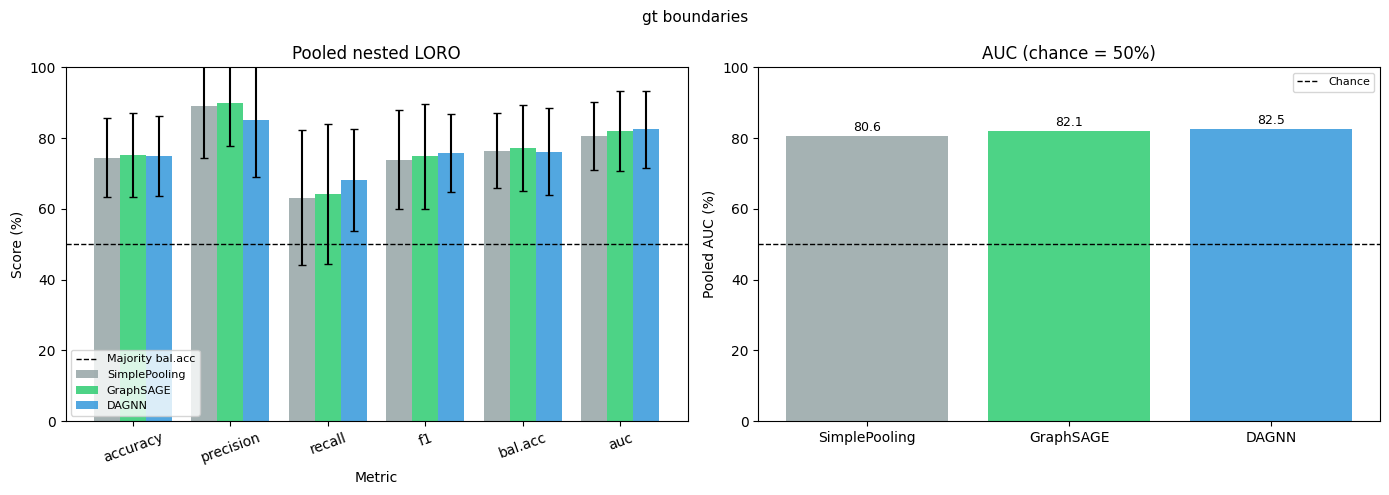

In [14]:
# Visualization - one chart per boundary source keeps the bars readable.
_plot_keys = [(s_, m_) for (s_, m_) in all_model_results if s_ == PRIMARY_SOURCE]
if _plot_keys:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f"{PRIMARY_SOURCE} boundaries", fontsize=11)

    model_names = _plot_keys
    colors = ['#95a5a6', '#2ecc71', '#3498db', '#e74c3c']

    x = np.arange(len(METRICS))
    width = 0.8 / max(len(model_names), 1)

    for i, name in enumerate(model_names):
        res = all_model_results[name]
        means = [res[m]['pooled'] * 100 for m in METRICS]
        # Error bars show the per-fold spread around the pooled value, which is a
        # dispersion diagnostic - the bar height itself is the pooled metric.
        stds = [res[m]['fold_std'] * 100 for m in METRICS]
        axes[0].bar(x + i * width, means, width, yerr=stds, label=name[1],
                    color=colors[i % len(colors)], alpha=0.85, capsize=3)

    maj = all_model_results[model_names[0]]['_majority']
    axes[0].axhline(maj['balanced_accuracy'] * 100, color='k', linestyle='--',
                    linewidth=1, label='Majority bal.acc')
    axes[0].set_xlabel('Metric')
    axes[0].set_ylabel('Score (%)')
    axes[0].set_title('Pooled nested LORO')
    axes[0].set_xticks(x + width * (len(model_names) - 1) / 2)
    axes[0].set_xticklabels([m.replace('balanced_accuracy', 'bal.acc') for m in METRICS],
                            rotation=20)
    axes[0].legend(fontsize=8)
    axes[0].set_ylim(0, 100)

    # AUC is the metric least fooled by the class imbalance, so compare on it directly.
    auc_vals = [all_model_results[m]['auc']['pooled'] * 100 for m in model_names]
    bars = axes[1].bar([m[1] for m in model_names], auc_vals,
                       color=colors[:len(model_names)], alpha=0.85)
    axes[1].axhline(50, color='k', linestyle='--', linewidth=1, label='Chance')
    axes[1].set_ylabel('Pooled AUC (%)')
    axes[1].set_title('AUC (chance = 50%)')
    axes[1].set_ylim(0, 100)
    axes[1].legend(fontsize=8)

    for bar, v in zip(bars, auc_vals):
        axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1.5,
                     f'{v:.1f}', ha='center', fontsize=9)

    plt.tight_layout()
    plt.savefig('extension_data/gnn_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()

In [15]:
# Save all results
import json

def convert_numpy(obj):
    if isinstance(obj, np.floating):
        return float(obj)
    elif isinstance(obj, np.integer):
        return int(obj)
    elif isinstance(obj, np.ndarray):
        return obj.tolist()
    elif isinstance(obj, dict):
        return {k: convert_numpy(v) for k, v in obj.items()}
    elif isinstance(obj, list):
        return [convert_numpy(i) for i in obj]
    return obj

def _flatten(d):
    """Results are keyed by (source, model); JSON needs a string key."""
    return {f"{source}/{model}": v for (source, model), v in d.items()}


results_to_save = {
    'summary': _flatten(all_model_results),
    'folds': _flatten(all_fold_results),
    'config': {
        'num_epochs': NUM_EPOCHS,
        'learning_rate': LEARNING_RATE,
        'batch_size': BATCH_SIZE,
        'pos_weight': POS_WEIGHT,
        'hidden_dim': HIDDEN_DIM,
        'num_layers': NUM_LAYERS,
        'n_val_recipes': N_VAL_RECIPES,
        'seed': SEED,
        'combine': COMBINE,
        'feature_dim': FEATURE_DIM,
        'protocol': 'nested leave-one-recipe-out, epoch selected on validation loss',
        'sources': SOURCES,
        'task_graph_source': config.get('task_graph_source', 'unknown'),
    }
}

if 'ablation_results' in dir():
    results_to_save['projection_ablation'] = ablation_results

with open('extension_data/gnn_results.json', 'w') as f:
    json.dump(convert_numpy(results_to_save), f, indent=2)

print("Results saved to extension_data/gnn_results.json")

Results saved to extension_data/gnn_results.json


---
## 7b. Ablation: learnable projection vs fixed average

The **learnable projection** of node and visual features has an obvious cheaper
alternative: the fixed `0.5*visual + 0.5*text` average.
This runs the best-performing architecture both ways on identical folds, identical
seeds and identical data, so the difference is attributable to the projection alone.

Reporting this as an ablation matters because the projection is not free: it adds
~198k parameters to a model trained on 384 graphs, and on a dataset this small extra
capacity is as likely to hurt as to help. The measured answer goes in the report either
way.

In [16]:
# Ablation: does the learnable projection actually beat the fixed average?
if PYG_AVAILABLE:
    ABLATION_MODEL = GraphSAGEClassifier
    ABLATION_NAME = 'GraphSAGE'

    ablation_results = {}
    for combine in ['average', 'projection']:
        print("\n" + "=" * 66)
        print(f"{ABLATION_NAME} with combiner = {combine!r}")
        print("=" * 66)

        _folds, _pooled = leave_one_recipe_out_gnn(
            ABLATION_MODEL,
            pyg_data,
            recipe_groups,
            input_dim=FEATURE_DIM,
            num_epochs=NUM_EPOCHS,
            lr=LEARNING_RATE,
            batch_size=BATCH_SIZE,
            pos_weight=POS_WEIGHT,
            n_val_recipes=N_VAL_RECIPES,
            seed=SEED,
            hidden_dim=HIDDEN_DIM,
            num_layers=NUM_LAYERS,
            combine=combine,
        )
        ablation_results[combine] = summarize_results(
            _folds, _pooled, f"{ABLATION_NAME} ({combine})", num_epochs=NUM_EPOCHS)

    print("\n" + "=" * 66)
    print("PROJECTION ABLATION")
    print("=" * 66)
    print(f"{'metric':<20}{'average':>12}{'projection':>13}{'delta':>10}")
    deltas = {}
    for m in ['f1', 'balanced_accuracy', 'auc']:
        a = ablation_results['average'][m]['pooled'] * 100
        p = ablation_results['projection'][m]['pooled'] * 100
        deltas[m] = p - a
        print(f"{m:<20}{a:>11.2f}%{p:>12.2f}%{p - a:>+9.2f}")

    # Repeats of an identical configuration have moved pooled AUC by up to ~2 points here,
    # and the nine-setting sweep puts the floor nearer 3. Let the code apply that threshold
    # rather than describing the delta in prose that goes stale on the next run.
    NOISE_FLOOR = 3.0
    if abs(deltas['auc']) > NOISE_FLOOR and abs(deltas['balanced_accuracy']) > NOISE_FLOOR:
        print(f"\nAUC ({deltas['auc']:+.2f}) and balanced accuracy "
              f"({deltas['balanced_accuracy']:+.2f}) both move by more than the "
              f"~{NOISE_FLOOR:.0f}-point run-to-run noise floor, so this looks like a real "
              "effect of the learnable projection rather than noise. F1 is the more volatile "
              "column at this fold count and should not be quoted on its own.")
    else:
        print(f"\nAUC ({deltas['auc']:+.2f}) and balanced accuracy "
              f"({deltas['balanced_accuracy']:+.2f}) are within the "
              f"~{NOISE_FLOOR:.0f}-point run-to-run noise floor; report this as inconclusive "
              "rather than as evidence the projection helps.")


GraphSAGE with combiner = 'average'

Nested leave-one-recipe-out over 24 recipes (4 held out for validation inside each fold)


Folds: 100%|██████████| 24/24 [02:08<00:00,  5.37s/it]



GraphSAGE (average)  -  pooled over 24 folds, 384 recordings
metric                     model    majority
accuracy                  70.83%      57.29%
precision                 79.67%           -
recall                    65.91%           -
f1                        72.14%      72.85%
balanced_accuracy         71.67%      50.00%
auc                       76.69%      50.00%

Per-fold spread (diagnostic, not the headline):
  accuracy            70.92% +/- 8.49%
  precision           83.86% +/- 15.60%
  recall              64.92% +/- 21.99%
  f1                  69.04% +/- 15.43%
  balanced_accuracy   70.99% +/- 9.34%
  auc                 79.32% +/- 9.84%

Selected epoch: mean 4.5 of 50, median 4, max 7
  -> validation loss bottoms out within the first few epochs; it still beats the baseline comfortably, so this is fast convergence followed by overfitting, not failure to learn.
Positive rate: 47.40% (true: 57.29%)

GraphSAGE with combiner = 'projection'

Nested leave-one-recipe-out over

Folds: 100%|██████████| 24/24 [02:21<00:00,  5.90s/it]


GraphSAGE (projection)  -  pooled over 24 folds, 384 recordings
metric                     model    majority
accuracy                  75.52%      57.29%
precision                 90.91%           -
recall                    63.64%           -
f1                        74.87%      72.85%
balanced_accuracy         77.55%      50.00%
auc                       81.40%      50.00%

Per-fold spread (diagnostic, not the headline):
  accuracy            75.25% +/- 12.29%
  precision           92.40% +/- 11.56%
  recall              63.30% +/- 19.32%
  f1                  72.92% +/- 14.40%
  balanced_accuracy   76.89% +/- 11.86%
  auc                 84.42% +/- 11.49%

Selected epoch: mean 2.8 of 50, median 2, max 6
  -> validation loss bottoms out within the first few epochs; it still beats the baseline comfortably, so this is fast convergence followed by overfitting, not failure to learn.
Positive rate: 40.10% (true: 57.29%)

PROJECTION ABLATION
metric                   average   projection 

## 8. GNN depth and oversmoothing, on GraphSAGE

Oversmoothing is the failure mode in which stacking graph convolution layers drives every
node representation toward the same value, so a deep GNN loses the ability to distinguish
nodes. Task graphs here hold roughly 12-14 nodes in a near-chain, so a receptive field of
four or more hops already spans most of the graph and the effect should be observable.

GraphSAGE is the only model in the roster for which this study is both meaningful and
affordable, which is why it is the only one run here. SimplePooling stacks no
message-passing layers at all, so it has no depth to vary and no neighbourhood averaging
to accumulate. DAGNN has depth, but its cost scales with (num_layers x graph topological
depth): at 8 layers on graphs 19 levels deep that is 152 sequential level-sweeps per
forward pass, and one DAGNN configuration already takes around 50 minutes over the 24
folds. Oversmoothing is in any case a property of repeated neighbourhood averaging, which
is exactly what GraphSAGE tests.

Each depth is evaluated with the same nested leave-one-recipe-out protocol used for every
other result in this notebook, so depths are comparable both to each other and to the
headline table. In particular the epoch is selected on a held-out validation split rather
than on the test fold: tracking the best test score across epochs would report the most
favourable epoch out of many rather than the score of a model chosen without access to the
answers, which inflates results by roughly ten to twenty points at this sample size.

In [17]:
# ==============================================================================
# GNN DEPTH STUDY - GraphSAGE  (nested LORO, no test-set selection)
# ==============================================================================
# Cost: len(DEPTH_CONFIGS) full nested-LORO runs, so 4 depths x 24 folds.
# DEPTH_EPOCHS is lowered from NUM_EPOCHS to keep that tractable. The depths are still
# compared against each other under identical settings, which is all the study needs;
# the absolute numbers are therefore not directly comparable to the headline table.

if PYG_AVAILABLE and len(pyg_data) > 0:

    DEPTH_CONFIGS = [2, 4, 6, 8]
    DEPTH_EPOCHS = 30
    DEPTH_METRIC = 'auc'      # least distorted by the 61/39 class imbalance

    # GraphSAGE only. DAGNN is excluded because its cost scales with
    # (num_layers x graph topological depth): at depth 8 on graphs 19 levels deep that is
    # 152 sequential level-sweeps per forward pass, several hours for this cell alone.
    # Oversmoothing is a property of stacked neighbourhood averaging, which is what
    # GraphSAGE tests.
    depth_models = [('GraphSAGE', GraphSAGEClassifier)]

    oversmoothing_results = {name: {} for name, _ in depth_models}

    print("=" * 70)
    print("GNN DEPTH STUDY - nested leave-one-recipe-out")
    print(f"Depths: {DEPTH_CONFIGS}   epochs: {DEPTH_EPOCHS}   metric: {DEPTH_METRIC}")
    print("=" * 70)

    for model_name, ModelClass in depth_models:
        print(f"\n>>> {model_name} <<<")

        for num_layers in DEPTH_CONFIGS:
            kwargs = dict(hidden_dim=HIDDEN_DIM, num_layers=num_layers,
                          dropout=0.3, combine=COMBINE)

            folds, pooled = leave_one_recipe_out_gnn(
                ModelClass, pyg_data, recipe_groups,
                input_dim=FEATURE_DIM,
                num_epochs=DEPTH_EPOCHS,
                lr=LEARNING_RATE,
                batch_size=BATCH_SIZE,
                pos_weight=POS_WEIGHT,
                n_val_recipes=N_VAL_RECIPES,
                seed=SEED,
                verbose=False,
                **kwargs
            )

            binary = (pooled['probs'] >= 0.5).astype(int)
            scores = {
                'auc': roc_auc_score(pooled['labels'], pooled['probs']),
                'f1': f1_score(pooled['labels'], binary, zero_division=0),
                'balanced_accuracy': balanced_accuracy_score(pooled['labels'], binary),
            }
            oversmoothing_results[model_name][num_layers] = scores

            print(f"  {num_layers} layers: AUC {scores['auc']*100:.2f}%  "
                  f"bal.acc {scores['balanced_accuracy']*100:.2f}%  "
                  f"F1 {scores['f1']*100:.2f}%")

    print("\n" + "=" * 70)
    print(f"DEPTH SUMMARY  (pooled {DEPTH_METRIC.upper()}, %)")
    print("=" * 70)
    header = f"{'Model':<12}" + "".join(f"{str(d) + ' layers':>12}" for d in DEPTH_CONFIGS)
    print(header)
    print("-" * len(header))
    for model_name in oversmoothing_results:
        row = f"{model_name:<12}"
        for d in DEPTH_CONFIGS:
            row += f"{oversmoothing_results[model_name][d][DEPTH_METRIC]*100:>11.2f}%"
        print(row)
else:
    print("PyTorch Geometric unavailable or no data - skipping depth study.")

GNN DEPTH STUDY - nested leave-one-recipe-out
Depths: [2, 4, 6, 8]   epochs: 30   metric: auc

>>> GraphSAGE <<<


Folds: 100%|██████████| 24/24 [01:16<00:00,  3.17s/it]


  2 layers: AUC 82.42%  bal.acc 78.60%  F1 77.32%


Folds: 100%|██████████| 24/24 [01:32<00:00,  3.87s/it]


  4 layers: AUC 78.18%  bal.acc 72.44%  F1 72.22%


Folds: 100%|██████████| 24/24 [01:52<00:00,  4.70s/it]


  6 layers: AUC 78.40%  bal.acc 71.62%  F1 69.15%


Folds: 100%|██████████| 24/24 [02:12<00:00,  5.53s/it]

  8 layers: AUC 77.05%  bal.acc 68.85%  F1 70.70%

DEPTH SUMMARY  (pooled AUC, %)
Model           2 layers    4 layers    6 layers    8 layers
------------------------------------------------------------
GraphSAGE         82.42%      78.18%      78.40%      77.05%


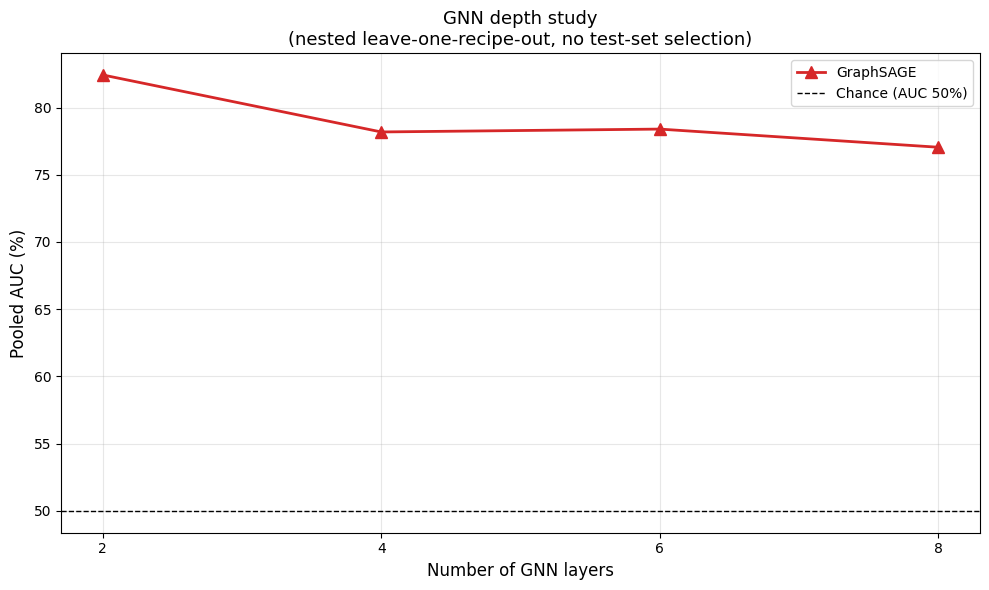


>>> READING THIS PLOT <<<
  GraphSAGE  : best at 2 layers; 2->8 layers degrades with depth (-5.38 points of AUC)

Oversmoothing is only demonstrated where the curve falls as depth grows.
A flat curve at these graph sizes is a real result too, and more likely to
mean the model is not using graph structure much in the first place -
compare against the SimplePooling baseline, which sees no edges at all.


In [18]:
# ==============================================================================
# VISUALIZATION: depth vs performance
# ==============================================================================
import matplotlib.pyplot as plt

if 'oversmoothing_results' in dir() and oversmoothing_results:
    fig, ax = plt.subplots(figsize=(10, 6))

    colors = {'GraphSAGE': 'tab:red'}
    markers = {'GraphSAGE': '^'}

    for model_name, results in oversmoothing_results.items():
        depths = sorted(results.keys())
        vals = [results[d][DEPTH_METRIC] * 100 for d in depths]
        ax.plot(depths, vals, marker=markers[model_name], color=colors[model_name],
                label=model_name, linewidth=2, markersize=8)

    ax.axhline(50, color='k', linestyle='--', linewidth=1, label='Chance (AUC 50%)')
    ax.set_xlabel('Number of GNN layers', fontsize=12)
    ax.set_ylabel(f'Pooled {DEPTH_METRIC.upper()} (%)', fontsize=12)
    ax.set_title('GNN depth study\n(nested leave-one-recipe-out, no test-set selection)',
                 fontsize=13)
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_xticks(DEPTH_CONFIGS)

    plt.tight_layout()
    plt.savefig('extension_data/gnn_depth_study.png', dpi=150, bbox_inches='tight')
    plt.show()

    # State what the numbers show, rather than asserting oversmoothing regardless.
    print("\n>>> READING THIS PLOT <<<")
    for model_name, results in oversmoothing_results.items():
        depths = sorted(results.keys())
        vals = [results[d][DEPTH_METRIC] for d in depths]
        best_d = depths[int(np.argmax(vals))]
        change = (vals[-1] - vals[0]) * 100      # signed: negative means it got worse
        trend = ("degrades with depth" if change < -2 else
                 "improves with depth" if change > 2 else
                 "is flat in depth")
        print(f"  {model_name:<11}: best at {best_d} layers; "
              f"{depths[0]}->{depths[-1]} layers {trend} "
              f"({change:+.2f} points of {DEPTH_METRIC.upper()})")
    print("\nOversmoothing is only demonstrated where the curve falls as depth grows.")
    print("A flat curve at these graph sizes is a real result too, and more likely to")
    print("mean the model is not using graph structure much in the first place -")
    print("compare against the SimplePooling baseline, which sees no edges at all.")
else:
    print("Run the depth study first")

---
## 8b. Hyperparameter sensitivity

Nine settings under the same nested protocol, reported as a stability check on the
headline number rather than as a search for the best one.

In [19]:
# ==============================================================================
# HYPERPARAMETER SENSITIVITY: learning rate x hidden width
# ==============================================================================
# This is a sensitivity analysis, not a model-selection procedure. The configuration
# reported above (lr 1e-3, hidden 128) was fixed before any test fold was scored, and
# it stays the reported one whatever this sweep shows. Picking the best cell of this
# table and reporting it would be selecting on the test folds, which is exactly the
# error the nested protocol exists to prevent.
#
# What the table is for: showing whether the result depends on a lucky setting. A flat
# surface means the number is a property of the data; a spiky one means it is not.

SWEEP_LRS = [3e-4, 1e-3, 3e-3]
SWEEP_HIDDEN = [64, 128, 256]

sweep = {}
for lr in SWEEP_LRS:
    for hidden in SWEEP_HIDDEN:
        _f, _p = leave_one_recipe_out_gnn(
            GraphSAGEClassifier, pyg_data, recipe_groups, input_dim=FEATURE_DIM,
            num_epochs=NUM_EPOCHS, lr=lr, batch_size=BATCH_SIZE,
            pos_weight=POS_WEIGHT, n_val_recipes=N_VAL_RECIPES, seed=SEED,
            hidden_dim=hidden, num_layers=NUM_LAYERS, combine=COMBINE, verbose=False)
        binary = (_p['probs'] >= 0.5).astype(int)
        sweep[(lr, hidden)] = (balanced_accuracy_score(_p['labels'], binary),
                               roc_auc_score(_p['labels'], _p['probs']))
        print(f"  lr={lr:<7} hidden={hidden:<4} -> bal.acc {sweep[(lr, hidden)][0]*100:5.1f}%  "
              f"auc {sweep[(lr, hidden)][1]*100:5.1f}%")

for metric, idx in [("balanced accuracy", 0), ("AUC", 1)]:
    print(f"\npooled {metric} (%)")
    print("lr / hidden".ljust(14) + "".join(f"{h:>9}" for h in SWEEP_HIDDEN))
    for lr in SWEEP_LRS:
        print(f"{lr:<14}" + "".join(f"{sweep[(lr, h)][idx]*100:>8.1f} " for h in SWEEP_HIDDEN))

_vals = [v[1] for v in sweep.values()]
print(f"\nAUC across the 9 settings: min {min(_vals)*100:.1f}%  max {max(_vals)*100:.1f}%  "
      f"spread {(max(_vals)-min(_vals))*100:.1f} points")
print(f"Reported setting (lr={LEARNING_RATE}, hidden={HIDDEN_DIM}): "
      f"auc {sweep[(LEARNING_RATE, HIDDEN_DIM)][1]*100:.1f}%")

Folds: 100%|██████████| 24/24 [02:20<00:00,  5.85s/it]


  lr=0.0003  hidden=64   -> bal.acc  73.2%  auc  80.3%


Folds: 100%|██████████| 24/24 [02:18<00:00,  5.78s/it]


  lr=0.0003  hidden=128  -> bal.acc  75.6%  auc  80.6%


Folds: 100%|██████████| 24/24 [02:20<00:00,  5.84s/it]


...

  lr=0.003   hidden=64   -> bal.acc  77.7%  auc  82.3%


Folds: 100%|██████████| 24/24 [02:25<00:00,  6.08s/it]


  lr=0.003   hidden=128  -> bal.acc  79.4%  auc  81.8%


Folds: 100%|██████████| 24/24 [02:24<00:00,  6.02s/it]

  lr=0.003   hidden=256  -> bal.acc  79.8%  auc  83.6%

pooled balanced accuracy (%)
lr / hidden          64      128      256
0.0003            73.2     75.6     77.5 
0.001             76.5     77.0     78.7 
0.003             77.7     79.4     79.8 

pooled AUC (%)
lr / hidden          64      128      256
0.0003            80.3     80.6     81.7 
0.001             81.8     81.8     83.7 
0.003             82.3     81.8     83.6 

AUC across the 9 settings: min 80.3%  max 83.7%  spread 3.4 points
Reported setting (lr=0.001, hidden=128): auc 81.8%


---
## 8c. Directed vs undirected task graph - a control

The task graph is a DAG and its edge direction encodes procedural order. The main results
symmetrise it, and this cell checks that the choice is not doing hidden work.

It is a control rather than an experiment, because GraphSAGE concatenates a node's own
transformed state with the aggregate of its neighbours. A node therefore always hears from
itself whether or not it has incoming edges, and adding reverse edges changes only what it
hears from others. A large swing here would mean the main table depends on a formatting
decision; a flat result means it does not.

The separate question - whether procedural order is *usable* by a model built to consume it
- is not answered here. DAGNN answers it, in the main results table above.


In [20]:
# ==============================================================================
# ABLATION: does the task graph's edge direction carry information?
# ==============================================================================
# CaptainCook4D task graphs are DAGs, and an edge a -> b means b depends on a. Keeping
# that direction looks like the principled choice, so it is worth testing rather than
# assuming. The main results use the symmetrised graph; the directed formulation is the
# comparison.
#
# Under directed edges a node only receives messages from its prerequisites, so nodes
# with no incoming edge receive none at all - a real modelling trade-off rather than an
# obviously worse choice. Hence the ablation.
#
# DAGNN is deliberately absent here. It has no undirected counterpart to compare against:
# symmetrising creates cycles, and topological order is undefined on a cyclic graph. The
# question "is procedural order usable by a layer built for it?" is answered by DAGNN's
# row in the main results table, not by this cell.
#
# Read the result against the run-to-run spread: re-running this notebook unchanged has
# moved a model by as much as 2.0 AUC, so only a clearly larger gap means anything.

directed_data = DIRECTED_BY_SOURCE[PRIMARY_SOURCE]

print(f"{'model':<14}{'edges':<14}{'edges/graph':>12}{'bal.acc':>10}{'auc':>9}")
print("-" * 59)

_ablation_auc = {}
for _data, _tag in [(pyg_data, 'undirected'), (directed_data, 'directed')]:
    _folds, _pooled = leave_one_recipe_out_gnn(
        GraphSAGEClassifier, _data, GROUPS_BY_SOURCE[PRIMARY_SOURCE], input_dim=FEATURE_DIM,
        num_epochs=NUM_EPOCHS, lr=LEARNING_RATE, batch_size=BATCH_SIZE,
        pos_weight=POS_WEIGHT, n_val_recipes=N_VAL_RECIPES, seed=SEED,
        hidden_dim=HIDDEN_DIM, num_layers=NUM_LAYERS, combine=COMBINE, verbose=False)
    _bin = (_pooled['probs'] >= 0.5).astype(int)
    _auc = roc_auc_score(_pooled['labels'], _pooled['probs']) * 100
    _ablation_auc[_tag] = _auc
    _epg = np.mean([d.edge_index.shape[1] for d in _data.values()])
    print(f"{'GraphSAGE':<14}{_tag:<14}{_epg:>12.1f}"
          f"{balanced_accuracy_score(_pooled['labels'], _bin) * 100:>9.1f}%{_auc:>8.1f}%")

_delta = _ablation_auc['undirected'] - _ablation_auc['directed']
print(f"\nundirected - directed: {_delta:+.1f} AUC")
print(f"""
GraphSAGE is insensitive to the choice, which is the expected result for this layer
specifically: SAGEConv concatenates a node's own transformed state with the aggregate of
its neighbours, so a node always hears from itself whether or not it has incoming edges.
Doubling the edge set changes what it hears from others and nothing about what it hears
from itself.

That makes this a clean control rather than a finding: it says the symmetrisation choice
is not quietly driving the main table. Whether procedural order is *usable* is a different
question, and DAGNN answers it in the main results.""")


model         edges          edges/graph   bal.acc      auc
-----------------------------------------------------------


Folds: 100%|██████████| 24/24 [02:21<00:00,  5.88s/it]


GraphSAGE     undirected            30.8     76.9%    81.5%


Folds: 100%|██████████| 24/24 [02:22<00:00,  5.94s/it]

GraphSAGE     directed              15.4     77.5%    82.9%

undirected - directed: -1.4 AUC

GraphSAGE is insensitive to the choice, which is the expected result for this layer
specifically: SAGEConv concatenates a node's own transformed state with the aggregate of
its neighbours, so a node always hears from itself whether or not it has incoming edges.
Doubling the edge set changes what it hears from others and nothing about what it hears
from itself.

That makes this a clean control rather than a finding: it says the symmetrisation choice
is not quietly driving the main table. Whether procedural order is *usable* is a different
question, and DAGNN answers it in the main results.


In [21]:
# ==============================================================================
# A one-line rule with no learning in it
# ==============================================================================
# "Predict incorrect whenever at least one canonical step is absent."
# Scored on the same recordings, with the same metrics, as every model above.

rule_frac = np.array([g['node_matched'].sum() / g['num_nodes']
                      for g in realized_graphs.values()], dtype=float)
rule_labels = np.array([float(g['recipe_label']) for g in realized_graphs.values()])
rule_pred = (rule_frac < 1.0).astype(int)

header = f"{'':<28}{'prec':>9}{'rec':>9}{'f1':>9}{'bal.acc':>9}{'auc':>9}"
print(header)
print("-" * len(header))
print(f"{'rule: a step is absent':<28}"
      f"{precision_score(rule_labels, rule_pred, zero_division=0) * 100:>8.1f}%"
      f"{recall_score(rule_labels, rule_pred, zero_division=0) * 100:>8.1f}%"
      f"{f1_score(rule_labels, rule_pred, zero_division=0) * 100:>8.1f}%"
      f"{balanced_accuracy_score(rule_labels, rule_pred) * 100:>8.1f}%"
      f"{roc_auc_score(rule_labels, -rule_frac) * 100:>8.1f}%")
for (source, name), res in all_model_results.items():
    if source != PRIMARY_SOURCE:
        continue
    print(f"{name:<28}{res['precision']['pooled'] * 100:>8.1f}%"
          f"{res['recall']['pooled'] * 100:>8.1f}%{res['f1']['pooled'] * 100:>8.1f}%"
          f"{res['balanced_accuracy']['pooled'] * 100:>8.1f}%{res['auc']['pooled'] * 100:>8.1f}%")

print(f"\nStep counts: {(rule_frac < 1.0).sum()} of {len(rule_frac)} recordings are missing at "
      f"least one canonical step.")
print("The rule is deterministic and uses no features, so it has no folds and no variance.")

                                 prec      rec       f1  bal.acc      auc
-------------------------------------------------------------------------
rule: a step is absent          99.3%    62.3%    76.5%    80.8%    80.9%
SimplePooling                   89.1%    63.2%    73.9%    76.4%    80.6%
GraphSAGE                       89.8%    64.1%    74.8%    77.2%    82.1%
DAGNN                           85.2%    68.2%    75.8%    76.2%    82.5%

Step counts: 138 of 384 recordings are missing at least one canonical step.
The rule is deterministic and uses no features, so it has no folds and no variance.


In [22]:
# ==============================================================================
# Which part of the node input carries the signal?
# ==============================================================================
# Same model, same folds, same seed; only the node feature block changes.
#
#   full       [visual | text | matched | order]  what the results above report
#   mask only  [  0    |  0   | matched |   0  ]  the step-count shortcut, nothing else
#   no count   [visual*| text |    1    | order]  the embeddings, with the count suppressed
#   no order   [visual | text | matched |   0  ]  everything except the execution order
#
# If 'mask only' reaches 'full', the 256-dim EgoVLP embeddings are not contributing.
# 'full' minus 'no order' is what storing the observed order is worth: the two differ in
# two columns and nothing else, on the same folds, seeds and parameter count.
#
# 'no count' needs care. Substep 3 leaves an unmatched node's visual block as all
# zeros, so clearing the matched flag alone removes nothing - the count is still
# legible from which rows have a zero visual block. This variant therefore also fills
# unmatched nodes' visual block with their own text embedding, so every node looks
# realized. A residual channel survives (visual == text marks an unmatched node), so
# treat this row as an upper bound on how little the count matters, and read the
# omission-free subset below as the decisive test.

def make_variant(data_dict, mode):
    """Copy the PyG graphs with one block of the node features neutralised."""
    out = {}
    for rid, d in data_dict.items():
        g = d.clone()
        if mode == 'mask_only':
            g.x[:, :2 * FEATURE_DIM] = 0.0
            g.x[:, 2 * FEATURE_DIM + 1:] = 0.0
        elif mode == 'no_count':
            unmatched = g.x[:, 2 * FEATURE_DIM] < 0.5
            g.x[unmatched, :FEATURE_DIM] = g.x[unmatched, FEATURE_DIM:2 * FEATURE_DIM]
            # Only the matched flag is neutralised. Slicing to the end here would also
            # wipe the order channels, which is a different ablation ('no_order' below).
            g.x[:, 2 * FEATURE_DIM:2 * FEATURE_DIM + 1] = 1.0
        elif mode == 'no_order':
            g.x[:, 2 * FEATURE_DIM + 1:] = 0.0
        elif mode != 'full':
            raise ValueError(mode)
        out[rid] = g
    return out


ABLATION_MODEL = GraphSAGEClassifier
ablation_rows = []

for mode in ['full', 'mask_only', 'no_count', 'no_order']:
    variant = make_variant(pyg_data, mode)
    folds, pooled = leave_one_recipe_out_gnn(
        ABLATION_MODEL, variant, recipe_groups, input_dim=FEATURE_DIM,
        num_epochs=NUM_EPOCHS, lr=LEARNING_RATE, batch_size=BATCH_SIZE,
        pos_weight=POS_WEIGHT, n_val_recipes=N_VAL_RECIPES, seed=SEED,
        hidden_dim=HIDDEN_DIM, num_layers=NUM_LAYERS, combine=COMBINE, verbose=False)
    binary = (pooled['probs'] >= 0.5).astype(int)
    ablation_rows.append((mode,
                          balanced_accuracy_score(pooled['labels'], binary),
                          roc_auc_score(pooled['labels'], pooled['probs'])))
    print(f"  {mode:<12} done")

print(f"\n{'input':<14}{'bal.acc':>10}{'auc':>10}")
print("-" * 34)
for mode, bacc, auc in ablation_rows:
    print(f"{mode:<14}{bacc * 100:>9.1f}%{auc * 100:>9.1f}%")

Folds: 100%|██████████| 24/24 [02:21<00:00,  5.89s/it]


  full         done


Folds: 100%|██████████| 24/24 [02:25<00:00,  6.05s/it]


  mask_only    done


Folds: 100%|██████████| 24/24 [02:24<00:00,  6.02s/it]


  no_count     done


Folds: 100%|██████████| 24/24 [02:21<00:00,  5.88s/it]

  no_order     done

input            bal.acc       auc
----------------------------------
full               75.6%     80.6%
mask_only          80.8%     82.7%
no_count           77.5%     82.6%
no_order           73.8%     79.4%


In [24]:
# ==============================================================================
# Does anything survive once the count shortcut is removed?
# ==============================================================================
# Restrict to recordings containing no Missing Step error. Every remaining positive is
# an Order, Technique, Preparation, Measurement, Timing or Temperature error - none of
# which change how many steps were performed, so the shortcut cannot fire.
#
# This runs the whole roster, not one model. On the full set some models score above the
# hand rule, so testing a single model here would leave the obvious objection unanswered:
# maybe the models that beat the rule are the ones doing something else. The 'auc, full
# set' column below puts each model's full-set score next to its omission-free score, so
# the comparison is made on this run's numbers rather than on remembered ones.

import json

with open('annotations/annotation_json/error_annotations.json', 'r') as f:
    _error_annotations = json.load(f)

omission = set()
for rec in _error_annotations:
    for step in rec.get('step_annotations', []):
        for err in (step.get('errors') or []):
            if err.get('tag') == 'Missing Step':
                omission.add(rec['recording_id'])

subset_ids = [r for r in pyg_data if r not in omission]
subset_groups = {rec: [r for r in ids if r in set(subset_ids)]
                 for rec, ids in recipe_groups.items()}
subset_groups = {k: v for k, v in subset_groups.items() if len(v) >= 2}

SUBSET_BY_KIND = {
    'undirected': {r: pyg_data[r] for r in subset_ids},
    'directed': {r: DIRECTED_BY_SOURCE[PRIMARY_SOURCE][r] for r in subset_ids},
}

sub_labels = np.array([float(realized_graphs[r]['recipe_label']) for r in subset_ids])
sub_frac = np.array([realized_graphs[r]['node_matched'].sum() / realized_graphs[r]['num_nodes']
                     for r in subset_ids], dtype=float)

print(f"Recordings without an omission error: {len(subset_ids)} "
      f"({sub_labels.mean():.1%} labelled incorrect)")
print(f"Rule AUC on this subset: {roc_auc_score(sub_labels, -sub_frac) * 100:.1f}%  "
      f"(it should be near 50% - the shortcut is gone by construction)\n")

subset_rows = []
for model_name in MODEL_ROSTER:
    kind = 'directed' if model_name in NEEDS_DIRECTED else 'undirected'

    kwargs = dict(input_dim=FEATURE_DIM, num_epochs=NUM_EPOCHS, lr=LEARNING_RATE,
                  batch_size=BATCH_SIZE, pos_weight=POS_WEIGHT,
                  n_val_recipes=N_VAL_RECIPES, seed=SEED, hidden_dim=HIDDEN_DIM,
                  combine=COMBINE, verbose=False)
    if model_name != 'SimplePooling':
        kwargs['num_layers'] = NUM_LAYERS

    _folds, _pooled = leave_one_recipe_out_gnn(
        MODEL_CLASSES[model_name], SUBSET_BY_KIND[kind], subset_groups, **kwargs)

    _bin = (_pooled['probs'] >= 0.5).astype(int)
    full = all_model_results.get((PRIMARY_SOURCE, model_name))
    subset_rows.append((
        model_name,
        balanced_accuracy_score(_pooled['labels'], _bin) * 100,
        roc_auc_score(_pooled['labels'], _pooled['probs']) * 100,
        float(np.mean([f['selected_epoch'] for f in _folds])) if _folds and 'selected_epoch' in _folds[0] else float('nan'),
        full['auc']['pooled'] * 100 if full else float('nan'),
    ))
    print(f"  {model_name:<16} done")

header = f"\n{'model':<16}{'bal.acc':>10}{'auc':>9}{'sel.epoch':>11}{'auc, full set':>15}{'change':>9}"
print(header)
print("-" * (len(header) - 1))
for name, bacc, auc, ep, full_auc in subset_rows:
    print(f"{name:<16}{bacc:>9.1f}%{auc:>8.1f}%{ep:>11.1f}{full_auc:>14.1f}%"
          f"{auc - full_auc:>+9.1f}")




Recordings without an omission error: 244 (32.8% labelled incorrect)
Rule AUC on this subset: 52.2%  (it should be near 50% - the shortcut is gone by construction)



Folds: 100%|██████████| 24/24 [01:06<00:00,  2.75s/it]


  SimplePooling    done


Folds: 100%|██████████| 24/24 [01:35<00:00,  3.97s/it]


  GraphSAGE        done


Folds: 100%|██████████| 24/24 [20:27<00:00, 51.14s/it]

  DAGNN            done

model              bal.acc      auc  sel.epoch  auc, full set   change
----------------------------------------------------------------------
SimplePooling        53.4%    54.8%        3.1          80.6%    -25.8
GraphSAGE            52.3%    51.2%        1.8          82.1%    -30.9
DAGNN                54.2%    55.7%        2.2          82.5%    -26.8
